# Práctica 2: Obteniendo máximos y mínimos en dos dimensiones con distintos métodos

El objetivo de esta práctica es calcular máximos y mínimos en dos dimensiones para funciones que se conocen de forma analítica con los algoritmos estudiados en clase.

Para ello, vamos a analizar la siguiente función de dos variables

$$
f(x,y)=10\sin x \sin y + x^2 - y^2.
$$

1. **[2 pts]** Representar la función para $-4\leq x\leq 4$, $-4\leq y\leq 4$ en $3$ dimensiones, y también en $2$ dimensiones con **imshow**, en un grid $2000\times 2000$. 

   **Ayuda:** 
   - Para representar en 3 dimensiones, se recomienda importar **subplots** de **matplotlib.pyplot**, y escribir las siguientes líneas
   ***
       fig, ax = subplots(subplot_kw={"projection": "3d"})
   
       ax.plot_surface(data_x,data_y,data_z, cmap='patron')
   ***
   - **data_x** y **data_y** han de ser arrays de dos dimensiones, con las coordenadas $x$ e $y$ del grid, respectivamente. Para obtenerlos, se recomienda el uso de **meshgrid**.
   - Se recomienda utilizar el patrón de color **hsv** de **imshow**.

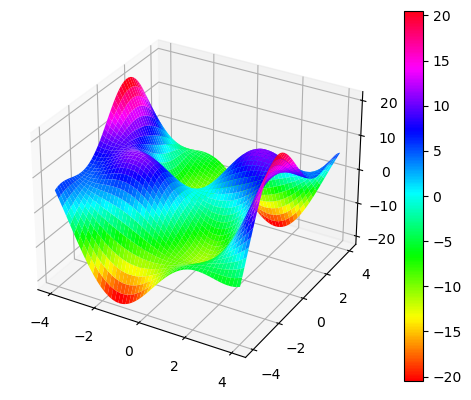

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = y = np.linspace(-4,4,2000)

X, Y = np.meshgrid(x, y)

f = lambda x, y: 10*np.sin(x)*np.sin(y)+x**2-y**2

Z = f(X, Y)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
plot3d = ax.plot_surface(X, Y, Z, cmap="hsv")
fig.colorbar(plot3d)
plt.show()

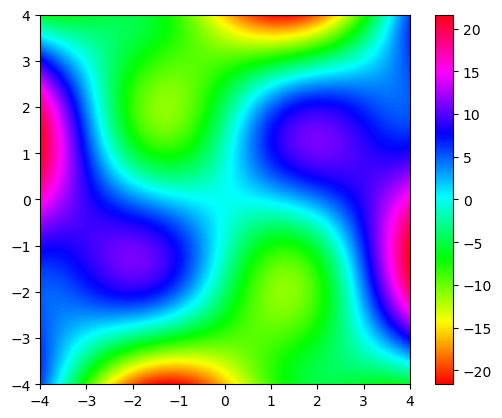

In [3]:
plt.imshow(Z, origin="lower", extent=[-4,4,-4,4], cmap="hsv")
plt.colorbar()
plt.show()

2. **[1 pt]** Elegir puntos iniciales para calcular los máximos y mínimos relativos de la función en la región $-4\leq x\leq 4$, $-4\leq y\leq 4$, y añadirlos a la representación de densidad.

   **Ayuda:** Se recomienda utilizar en **imshow** la opción **extent** para representar con facilidad los puntos iniciales escogidos.

**Nota:** se disciernen claramente 4 extremos: dos mínimos y dos máximos. Seleccionamos a ojo los puntos iniciales:

Máx: $(2,1),\ (-2,-1)$

Mín: $(1, -2), \ (-1, 2)$

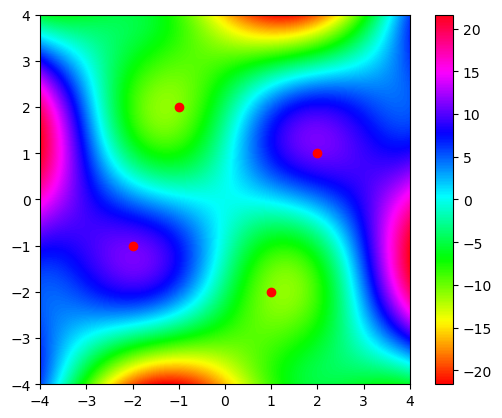

In [5]:
x_extremos = np.array([2,-2,1,-1], float)
y_extremos = np.array([1,-1,-2,2], float)

plt.imshow(Z, origin="lower", extent=[-4,4,-4,4], cmap="hsv")
plt.plot(x_extremos, y_extremos, "ro")
plt.colorbar()
plt.show()

3. **[3.5 pts]** Partiendo de los puntos iniciales anteriores, calcular los extremos relativos de la función con el método de Newton-Rapson (hacer uso de alguno de los métodos de resolución de ecuaciones lineales estudiados en clase) aplicado sobre las condiciones de extremo relativo. Añadir a la representación de densidad los extremos obtenidos. ¿Cuántas iteraciones son necesarias para alcanzar cada extremo?

In [4]:
# Sust. hacia atrás
import numpy as np

def sust_atras(A, B):
    N = len(B)
    x = np.empty_like(B)
    d = np.diag(A)
    
    for i in range(N-1, -1, -1):
        x[i] = B[i]
        for n in range(i+1, N):
            x[i] -= A[i, n]*x[n]
        x[i] /= d[i]
    return x

In [5]:
# Algoritmo para hacer matriz triang. sup. con pivote

import numpy as np
def make_triang_sup(AB):
    # 1. Ubico elemento máximo y pivoto
    # 2. Divido por pivote toda la fila
    # 3. Resto en cascada multiplicando por la cabeza de cada fila
    
    N = len(AB)
    for i in range(N): # Por cada fila
        col = AB[i:, i] # No puedo tomar como pivote de la fila 2 algo de la fila 1
        pivote = np.max(col)
        ind = np.where(col==pivote)[0][0] + i # No puedo tener en cuenta las filas superiores
        
        # Una vez ubicado el pivote, pivoto fila actual por la de interés
        AB[i,:], AB[ind, :] = AB[ind, :].copy(), AB[i, :].copy()
        
        # Ahora divido por el pivote de la fila
        AB[i,i:] /= pivote
        
        # Finalmente, multiplico por cabeza de cada fila y resto
        for j in range(i+1, N):
            head = AB[j, i]
            AB[j,i:] -= head*AB[i,i:] # Solo resto aquel subconjunto de las filas que es no nulo
        
    return AB

In [6]:
# Gauss completo con pivote

def solveGauss(A, B):
    AB = np.column_stack((A, B))
    triang = make_triang_sup(AB)
    
    A = AB[:,:-1]
    B = AB[:,-1]
    
    return sust_atras(A, B)

It. necesarias: 4
[2.00122031 1.28426033]
It. necesarias: 4
[-2.00122031 -1.28426033]
It. necesarias: 4
[ 1.28426033 -2.00122031]
It. necesarias: 4
[-1.28426033  2.00122031]


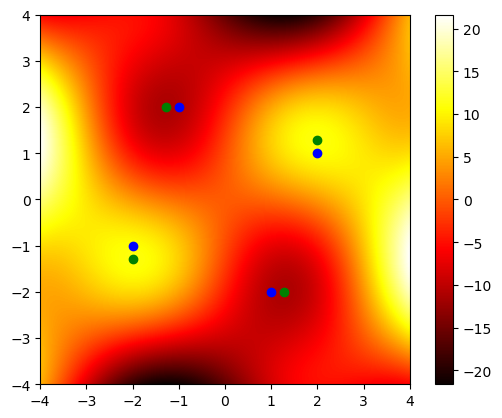

In [7]:
# Newton-Raphson en varias variables (sistemas de ecuaciones no lineales)

import numpy as np

f1 = lambda x, y: 10*np.cos(x)*np.sin(y)+2*x
f2 = lambda x, y: 10*np.sin(x)*np.cos(y)-2*y

J_1x = lambda x, y: -10*np.sin(x)*np.sin(y)+2
J_1y = lambda x, y: 10*np.cos(x)*np.cos(y)
J_2x = lambda x, y: 10*np.cos(x)*np.cos(y)
J_2y = lambda x, y: -10*np.sin(x)*np.sin(y)-2

def F(r):
    x, y = r
    return np.array([f1(x, y), f2(x, y)], float)

def J(r):
    x, y = r
    return np.array([[J_1x(x, y), J_1y(x, y)], [J_2x(x, y), J_2y(x, y)]], float)

def newton_raphson_Nvar(X0, tol):
    # Resolvemos el sistema lineal: JD_x = F. No podemos usar LU para actuar sobre J una sola vez porque hay que recalcularlo para cada x1
    err = 1.0
    cont=0
    while err > tol:
        cont+=1
        J0 = J(X0)
        F0 = F(X0)
        
        Dx = solveGauss(J0, F0)
        X1 = X0-Dx
        
        err = np.max(np.abs(X1-X0))
        X0=X1
        
    return X1, cont

extremos = []

for pt in zip(x_extremos, y_extremos):
    ext, cont = newton_raphson_Nvar(pt, 10**(-6))
    extremos.append(ext)
    plt.plot(ext[0], ext[1], "go")
    print(f"It. necesarias: {cont}")
    print(ext)


plt.imshow(Z, origin="lower", extent=[-4,4,-4,4], cmap="hot")
plt.plot(x_extremos, y_extremos, "bo")
plt.colorbar()
plt.show()

4. **[2.5 pts]** Partiendo de los mismos puntos iniciales, tratar de calcular los máximos y mínimos de la función con el método del punto fijo. Añadir a la representación de densidad los extremos obtenidos. ¿Converge el método?

    **Ayuda:** Se recomienda calcular un número fijo de iteraciones como máximo.

It. necesarias: 10000
[4.62199433 2.31099716]
It. necesarias: 10000
[-4.62199433 -2.31099716]
It. necesarias: 10000
[ 2.31099716 -4.62199433]
It. necesarias: 10000
[-2.31099716  4.62199433]


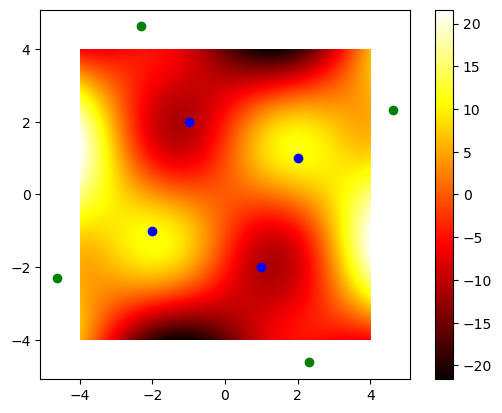

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def F(X):
    x, y = X
    return np.array([f1(x, y), f2(x, y)]) + X

def punto_fijo_Nvar(X0, tol):
    err = 1.0
    cont=0
    while cont<10**4:
        cont+=1
        X1 = F(X0)
        err = np.linalg.norm(X1-X0)
        X0=X1
    return X1, cont

extremos = []

for pt in zip(x_extremos, y_extremos):
    ext, cont = punto_fijo_Nvar(pt, 10**(-6))
    extremos.append(ext)
    plt.plot(ext[0], ext[1], "go")
    print(f"It. necesarias: {cont}")
    print(ext)


plt.imshow(Z, origin="lower", extent=[-4,4,-4,4], cmap="hot")
plt.plot(x_extremos, y_extremos, "bo")
plt.colorbar()
plt.show()

El método no converge.

5. **[1 pt + Extra]** Demostrar por qué converge o no el método del punto fijo utilizado en el apartado anterior. ¿Y si reescribes de otra forma?

Criterio de no-convergencia: $|\text{det }J(\vec x_{sol})|>1 \Longrightarrow $ No converge

In [9]:
print(np.abs(np.linalg.det(J([2,1.28]))))

70.46161989975097


Es mayor que la unidad, luego el método no converge. 

array([0.0045624, 0.0045624])